# ___Car Price Prediction with Machine Learning___

___Importing Libraries___

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

### ___1. Download Dataset___

In [2]:
df = pd.read_csv('cardata.csv')

print(df.shape)
print(df.head())
print(df.dtypes)
print(df.isnull().sum())

(8128, 12)
                           name  year  selling_price  km_driven    fuel  \
0        Maruti Swift Dzire VDI  2014         450000     145500  Diesel   
1  Skoda Rapid 1.5 TDI Ambition  2014         370000     120000  Diesel   
2      Honda City 2017-2020 EXi  2006         158000     140000  Petrol   
3     Hyundai i20 Sportz Diesel  2010         225000     127000  Diesel   
4        Maruti Swift VXI BSIII  2007         130000     120000  Petrol   

  seller_type transmission         owner  mileage(km/ltr/kg)  engine  \
0  Individual       Manual   First Owner               23.40  1248.0   
1  Individual       Manual  Second Owner               21.14  1498.0   
2  Individual       Manual   Third Owner               17.70  1497.0   
3  Individual       Manual   First Owner               23.00  1396.0   
4  Individual       Manual   First Owner               16.10  1298.0   

  max_power  seats  
0        74    5.0  
1    103.52    5.0  
2        78    5.0  
3        90    5.0  


### ___2. Data Cleaning___

In [3]:
categorical_cols = ['fuel', 'seller_type', 'transmission', 'owner']
for col in categorical_cols:
    df[col] = df[col].astype(str).str.strip().str.title()

for col in ['mileage(km/ltr/kg)', 'engine', 'max_power']:
    df[col] = df[col].astype(str).str.extract(r'([\d.]+)')
    df[col] = pd.to_numeric(df[col], errors='coerce')

# Handle missing values and duplicates
df.dropna(inplace=True)
df.drop_duplicates(inplace=True)

print(df['fuel'].unique())
print(df['seller_type'].unique())
print(df['transmission'].unique())
print(df['owner'].unique())
print(df.shape)

<ArrowStringArray>
['Diesel', 'Petrol', 'Lpg', 'Cng']
Length: 4, dtype: str
<ArrowStringArray>
['Individual', 'Dealer', 'Trustmark Dealer']
Length: 3, dtype: str
<ArrowStringArray>
['Manual', 'Automatic']
Length: 2, dtype: str
<ArrowStringArray>
[         'First Owner',         'Second Owner',          'Third Owner',
 'Fourth & Above Owner',       'Test Drive Car']
Length: 5, dtype: str
(6717, 12)


### ___3. Feature Engineering___

In [4]:
df['car_age'] = 2024 - df['year']
df['brand'] = df['name'].str.split().str[0]
print(df[['name', 'brand', 'year', 'car_age']].head())

                           name    brand  year  car_age
0        Maruti Swift Dzire VDI   Maruti  2014       10
1  Skoda Rapid 1.5 TDI Ambition    Skoda  2014       10
2      Honda City 2017-2020 EXi    Honda  2006       18
3     Hyundai i20 Sportz Diesel  Hyundai  2010       14
4        Maruti Swift VXI BSIII   Maruti  2007       17


### ___4. EDA___

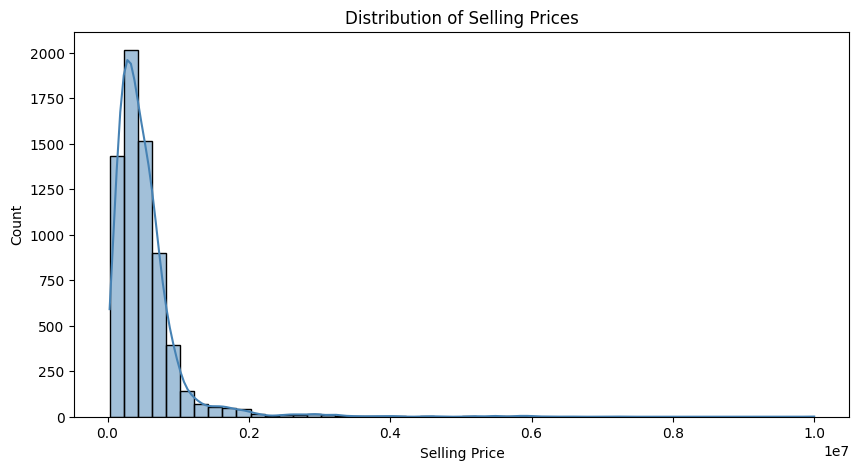

In [5]:
# 1. Distribution of selling prices
plt.figure(figsize=(10, 5))
sns.histplot(df['selling_price'], bins=50, kde=True, color='steelblue')
plt.title('Distribution of Selling Prices')
plt.xlabel('Selling Price')
plt.ylabel('Count')
plt.show()

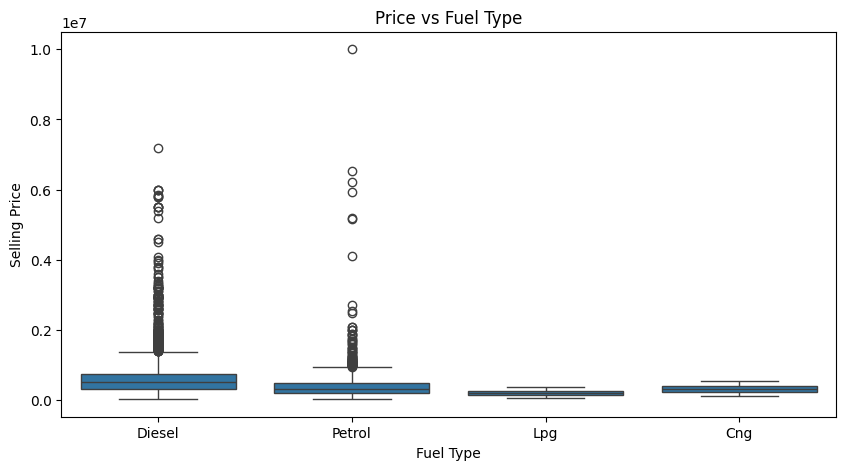

In [6]:
# 2. Price vs Fuel Type
plt.figure(figsize=(10, 5))
sns.boxplot(x='fuel', y='selling_price', data=df)
plt.title('Price vs Fuel Type')
plt.xlabel('Fuel Type')
plt.ylabel('Selling Price')
plt.show()

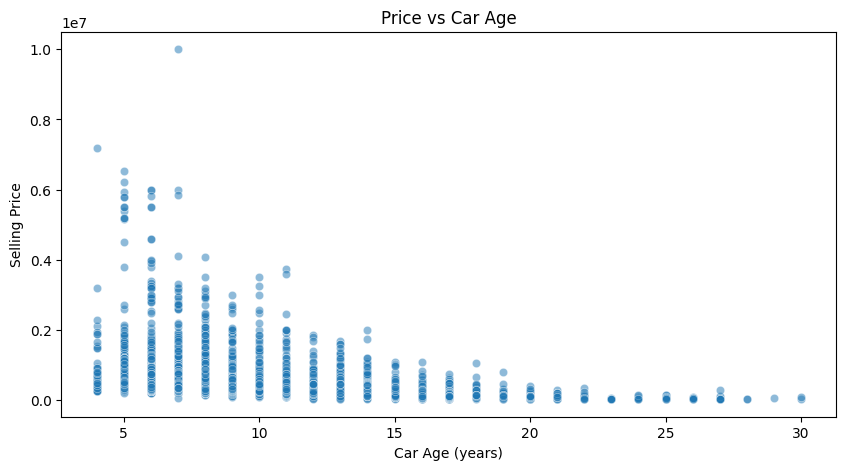

In [7]:
# 3. Price vs Car Age
plt.figure(figsize=(10, 5))
sns.scatterplot(x='car_age', y='selling_price', data=df, alpha=0.5)
plt.title('Price vs Car Age')
plt.xlabel('Car Age (years)')
plt.ylabel('Selling Price')
plt.show()

### ___5. Encode Categorical Variables___

In [8]:
le = LabelEncoder()
df['fuel_encoded'] = le.fit_transform(df['fuel'])
df['seller_type_encoded'] = le.fit_transform(df['seller_type'])
df['transmission_encoded'] = le.fit_transform(df['transmission'])
df['owner_encoded'] = le.fit_transform(df['owner'])
df['brand_encoded'] = le.fit_transform(df['brand'])

print(df[['fuel', 'fuel_encoded', 'transmission', 'transmission_encoded']].head())

     fuel  fuel_encoded transmission  transmission_encoded
0  Diesel             1       Manual                     1
1  Diesel             1       Manual                     1
2  Petrol             3       Manual                     1
3  Diesel             1       Manual                     1
4  Petrol             3       Manual                     1


### ___6. Feature Correlation Heatmap___

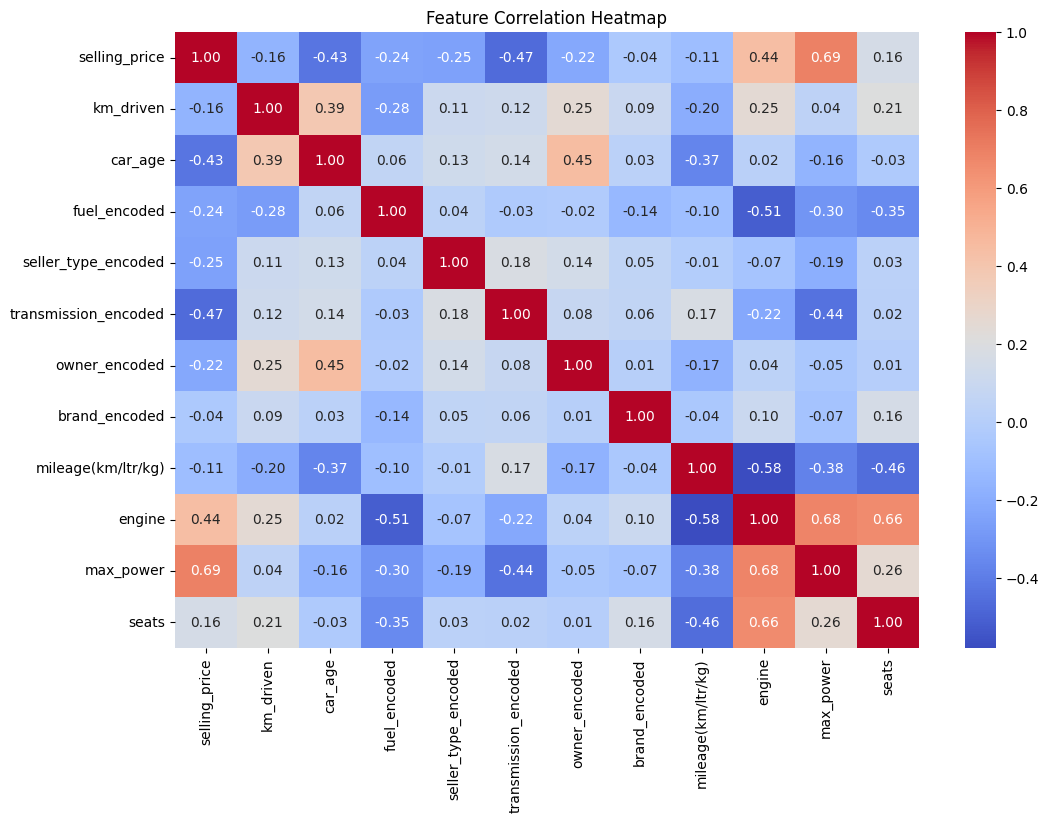

In [9]:
numeric_df = df[['selling_price', 'km_driven', 'car_age', 
                  'fuel_encoded', 'seller_type_encoded', 
                  'transmission_encoded', 'owner_encoded', 
                  'brand_encoded', 'mileage(km/ltr/kg)', 
                  'engine', 'max_power', 'seats']]

plt.figure(figsize=(12, 8))
sns.heatmap(numeric_df.corr(), annot=True, fmt='.2f', cmap='coolwarm')
plt.title('Feature Correlation Heatmap')
plt.show()

### ___7. Train/Test Split___

In [10]:
features = ['km_driven', 'car_age', 'fuel_encoded', 'seller_type_encoded',
            'transmission_encoded', 'owner_encoded', 'brand_encoded',
            'mileage(km/ltr/kg)', 'engine', 'max_power', 'seats']

X = df[features]
y = df['selling_price']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print("Training size:", X_train.shape)
print("Testing size:", X_test.shape)

Training size: (5373, 11)
Testing size: (1344, 11)


### ___8. Train 2 Regression Models___

In [11]:
# Model 1: Linear Regression
lr = LinearRegression()
lr.fit(X_train, y_train)
lr_pred = lr.predict(X_test)

In [12]:
# Model 2: Random Forest Regressor
rf = RandomForestRegressor(n_estimators=100, random_state=42)
rf.fit(X_train, y_train)
rf_pred = rf.predict(X_test)

### ___9. Evaluate Models___

In [13]:
print("LINEAR REGRESSION:")
print("MAE:", mean_absolute_error(y_test, lr_pred))
print("RMSE:", np.sqrt(mean_squared_error(y_test, lr_pred)))
print("R2 Score:", r2_score(y_test, lr_pred))

LINEAR REGRESSION:
MAE: 168548.56528684183
RMSE: 273251.25872263126
R2 Score: 0.6597275361174665


In [14]:
print("\nRANDOM FOREST REGRESSOR:")
print("MAE:", mean_absolute_error(y_test, rf_pred))
print("RMSE:", np.sqrt(mean_squared_error(y_test, rf_pred)))
print("R2 Score:", r2_score(y_test, rf_pred))


RANDOM FOREST REGRESSOR:
MAE: 75740.32789177354
RMSE: 132035.85637180568
R2 Score: 0.9205514022197965


### ___10. Feature Importance Chart___

C:\Users\Wajiz.pk\AppData\Local\Temp\ipykernel_16104\2252541122.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='importance', y='feature', data=feature_importance, palette='viridis')


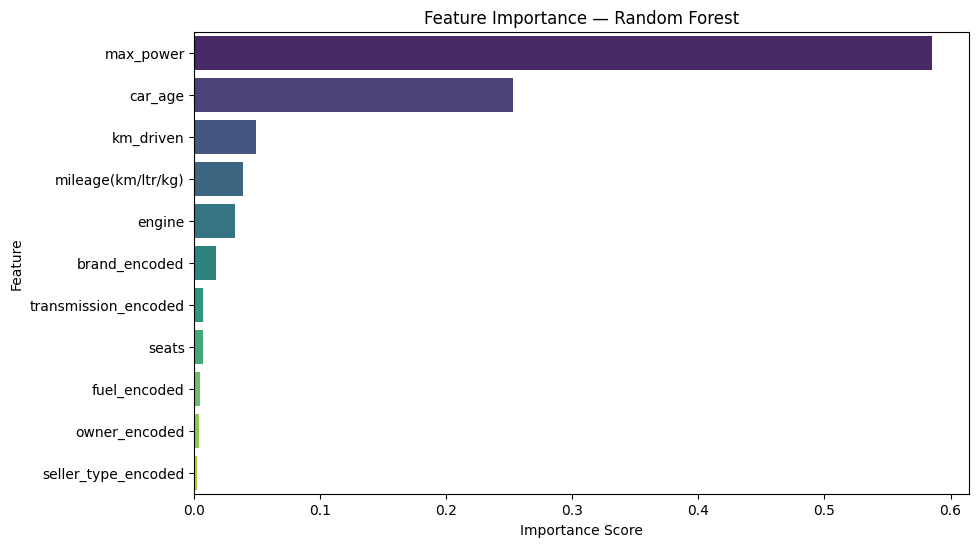

                 feature  importance
9              max_power    0.585709
1                car_age    0.252799
0              km_driven    0.049108
7     mileage(km/ltr/kg)    0.038895
8                 engine    0.032103
6          brand_encoded    0.017497
4   transmission_encoded    0.006963
10                 seats    0.006509
2           fuel_encoded    0.004450
5          owner_encoded    0.003851
3    seller_type_encoded    0.002115


In [15]:
feature_importance = pd.DataFrame({
    'feature': features,
    'importance': rf.feature_importances_
}).sort_values('importance', ascending=False)

plt.figure(figsize=(10, 6))
sns.barplot(x='importance', y='feature', data=feature_importance, palette='viridis')
plt.title('Feature Importance — Random Forest')
plt.xlabel('Importance Score')
plt.ylabel('Feature')
plt.show()

print(feature_importance)